In [18]:
from scripts.analysis import Analysis
import numpy as np
from scipy.constants import e, c, epsilon_0

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

/home/rsimpson/anaconda3/envs/Xtrack/lib/python3.13/site-packages/tables/attributeset.py:322: DataTypeWarning: Unsupported type for attribute 'thick' in node '/'. Offending HDF5 class: 8
  value = self._g_getattr(self._v_node, name)


0.004465332007025389
0.0043682198388036945


/home/rsimpson/anaconda3/envs/Xtrack/lib/python3.13/site-packages/tables/attributeset.py:322: DataTypeWarning: Unsupported type for attribute 'thick' in node '/'. Offending HDF5 class: 8
  value = self._g_getattr(self._v_node, name)


0.004465332007025389
0.0043682198388036945


/home/rsimpson/anaconda3/envs/Xtrack/lib/python3.13/site-packages/tables/attributeset.py:322: DataTypeWarning: Unsupported type for attribute 'thick' in node '/'. Offending HDF5 class: 8
  value = self._g_getattr(self._v_node, name)


...

0.004465332007025389
0.0043682198388036945


/home/rsimpson/anaconda3/envs/Xtrack/lib/python3.13/site-packages/tables/attributeset.py:322: DataTypeWarning: Unsupported type for attribute 'thick' in node '/'. Offending HDF5 class: 8
  value = self._g_getattr(self._v_node, name)


0.004465332007025389
0.0043682198388036945


/home/rsimpson/anaconda3/envs/Xtrack/lib/python3.13/site-packages/tables/attributeset.py:322: DataTypeWarning: Unsupported type for attribute 'thick' in node '/'. Offending HDF5 class: 8
  value = self._g_getattr(self._v_node, name)


0.004465332007025389
0.0043682198388036945


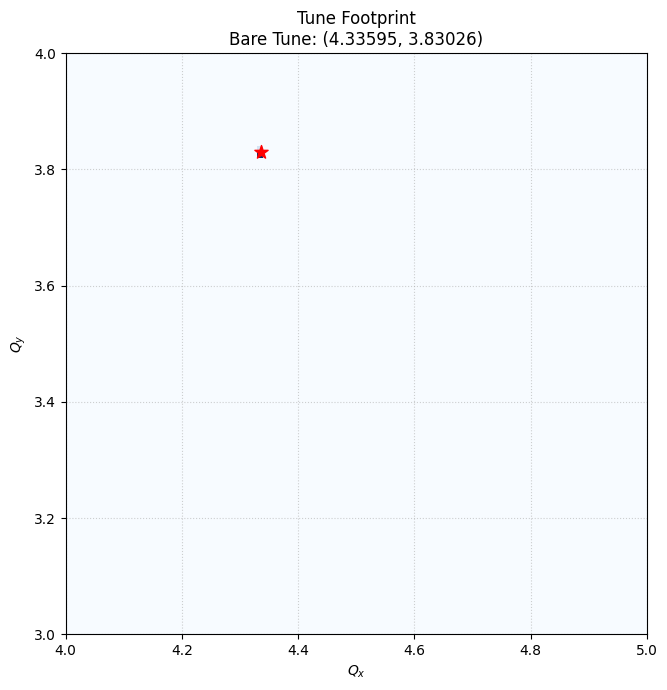

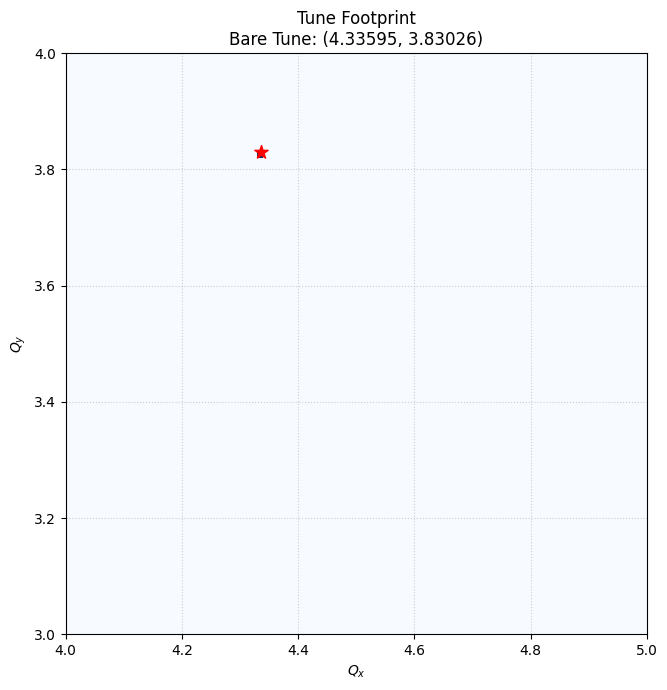

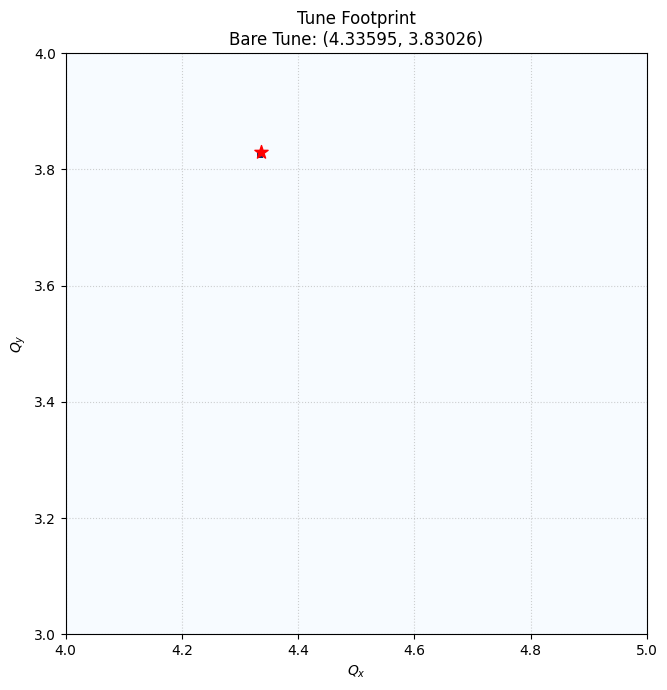

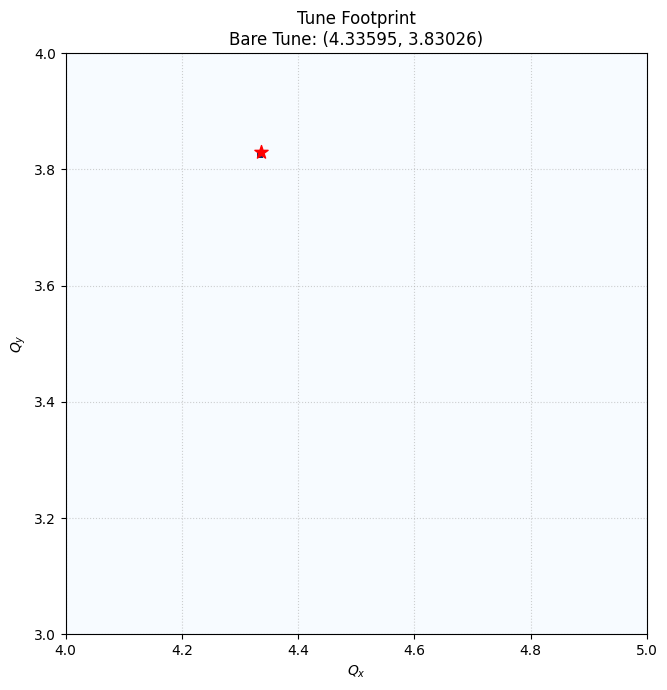

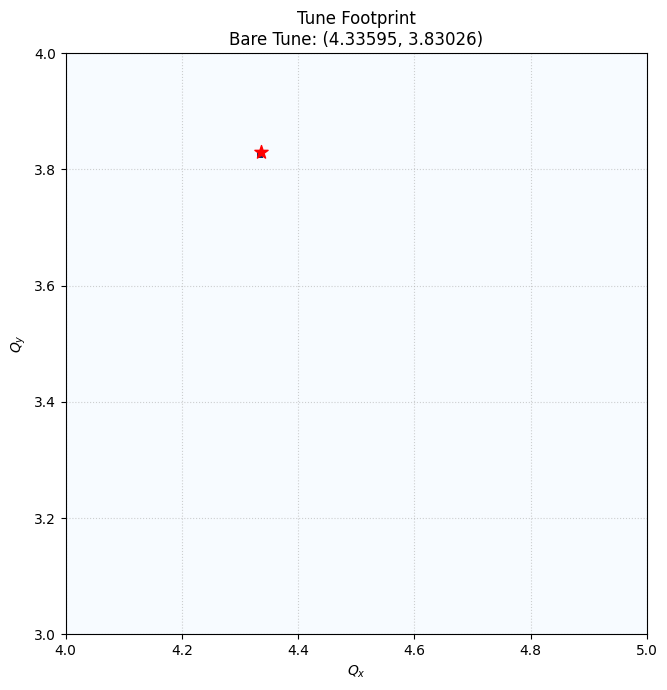

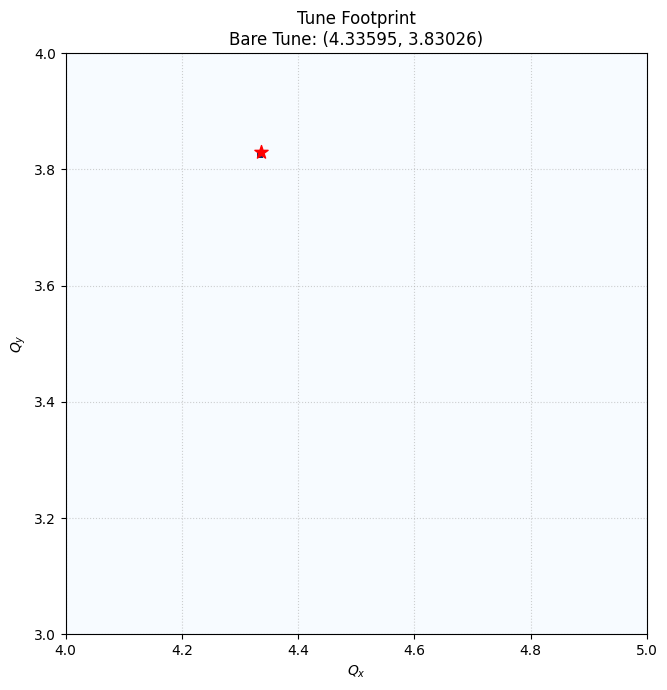

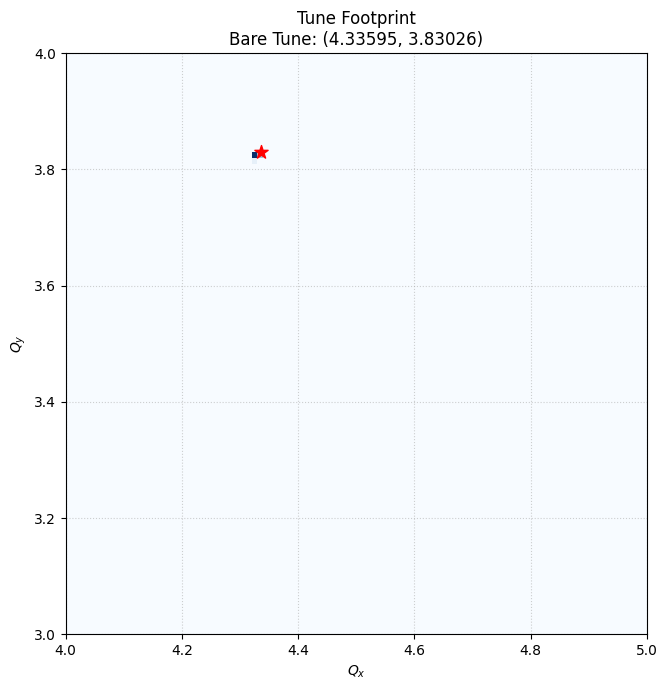

In [19]:
intensities  = [2e9, 4e9, 6e9, 8e9, 1e10, 2e10, 4e10, 6e10] 

shift_x_list = []
shift_y_list = []
expected_shift_x_list = []
expected_shift_y_list = []
R = 26 # ISIS sync radius
p0c = 0.37033168 * 1e9 # Injection momenta (constant through sim)

for i in intensities:
    a = Analysis(f'intensity_var_4/{str(i)}')
    a.tune_histogram(show=False)
    
    shift_x = -(np.max(a.qx - a.get_tune('x'))%1)
    shift_y = -(np.max(a.qy - a.get_tune('y'))%1)
    shift_x_list.append(shift_x)
    shift_y_list.append(shift_y)

    _lambda = i/(2*np.pi*R)
    K_sc = e*_lambda/(2*np.pi*epsilon_0 * a.beta * a.gamma**2 * p0c) # Space charge perveance
    
    expected_shift_x = - 2 * K_sc * R**2 / (4*a.sigma_x*(a.sigma_x + a.sigma_y) * a.qx)
    expected_shift_y = - 2 * K_sc * R**2 / (4*a.sigma_y*(a.sigma_x + a.sigma_y) * a.qy)
    expected_shift_x_list.append(expected_shift_x)
    expected_shift_y_list.append(expected_shift_y)
    print(a.sigma_x)
    print(a.sigma_y)
    
plt.close()

In [21]:
def model_origin(x, m):
    return m * x

def get_m(x_data, y_data):
    popt, pcov = curve_fit(model_origin, x_data, y_data)
    m_val = popt[0]
    m_error = np.sqrt(np.diag(pcov))[0]
    return m_val, m_error

mx, mx_err = get_m(intensities, shift_x_list)
my, my_err = get_m(intensities, shift_y_list)
mxt, mxt_err = get_m(intensities, expected_shift_x_list)
myt, myt_err = get_m(intensities, expected_shift_y_list)

shift_x_line = mx*np.array(intensities)
shift_y_line = my*np.array(intensities)

expected_shift_x_line = mxt*np.array(intensities)
expected_shift_y_line = myt*np.array(intensities)

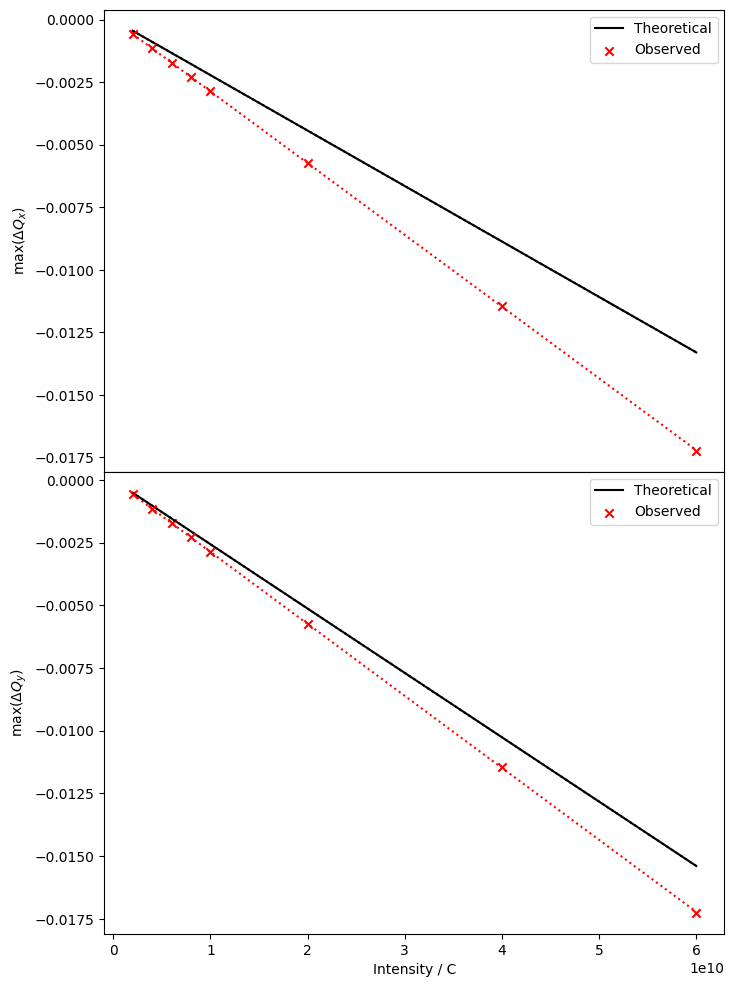

In [22]:
fig, axs = plt.subplots(2, figsize=(8,12), sharex=True)
axs[0].plot(intensities, expected_shift_x_list, zorder=1, label='Theoretical', c='k')
axs[0].scatter(intensities, shift_x_list, label='Observed', marker='x', c='r')

axs[0].plot(intensities, shift_x_line, ls=':', c='r')
axs[0].plot(intensities, expected_shift_x_line, ls=':', c='k')

axs[0].set_ylabel(r'$\text{max}(\Delta Q_x)$')
axs[0].legend()

axs[1].plot(intensities, expected_shift_y_list*1, zorder=1, label='Theoretical', c='k')
axs[1].scatter(intensities, shift_y_list, label='Observed', marker='x', c='r')

axs[1].plot(intensities, shift_y_line, ls=':', c='r')
axs[1].plot(intensities, expected_shift_y_line, ls=':', c='k')

axs[1].set_xlabel('Intensity / C')
axs[1].set_ylabel(r'$\text{max}(\Delta Q_y)$')
axs[1].legend()

plt.subplots_adjust(hspace=0)


In [24]:
print(f'{mx} +- {mx_err}')
print(f'{my} +- {my_err}')
print(f'{mxt} +- {mxt_err}')
print(f'{myt} +- {myt_err}')

-2.8680646166016095e-13 +- 2.397935464820794e-16
-2.870645222531979e-13 +- 2.9222907850432183e-16
-2.2170741614636213e-13 +- 1.3127373463853965e-29
-2.5655842482543477e-13 +- 9.004361419700482e-30


In [25]:
print(mx/mxt)
print(my/myt)

1.293625926661935
1.1189050698628191
